In [2]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import nnx
import nnx.functional as Fx
import nnx.graphics as G
import nnx.projection as P
import nnx.console as console

In [3]:
console.print("<pink~darkgray><b>Fx.tensor</><gray>(input, shape=(), device=None)")

console.print("\n<lime>tensors will be tensors")
a = Fx.tensor(torch.zeros(3))
print(a)

console.print("\n<lime>lists, tuples, sizes will be tensors")
a = Fx.tensor((1,2,3))
b = Fx.tensor([1.0,2,3])
c = Fx.tensor(a.shape)
print(a,b,c)

console.print("\n<lime>numbers will be tensors")
a = Fx.tensor(1)
b = Fx.tensor(1+2j)
print(a,b)

console.print("\n<lime>numbers will be expanded")
a = Fx.tensor(2, 3)
b = Fx.tensor(math.pi, 2)
print(a,b)

console.print("\n<lime>numbers will be expanded to any shape")
a = Fx.tensor(3+3j, (2,2))
print(a)

console.print("\n<lime>tensors are created recursively")
a = Fx.tensor([[1,2,3],[4,5,6],[7,8,9]])
print(a)

console.print("\n<lime>will silently <b>ignore</b> shape if input is list, tuple, size or tensor")
a = Fx.tensor([1,2,3], shape=[1]) 
print(a)

console.print("\n<lime>combinations of numbers and tensors is an option")
console.print("<gray>(must provide size for elements)")
scale = torch.randn(2,2)
matrix = [scale[:,:1], 0, 0, 0, scale[:,1:], 0, 0, 0, 1.]
matrix = Fx.tensor(matrix, shape=(2,-1)).unflatten(-1,(3,3))
print(matrix)

Fx.tensor(input, shape=(), device=None) 

tensors will be tensors 
tensor([0., 0., 0.])

lists, tuples, sizes will be tensors 
tensor([1, 2, 3]) tensor([1., 2., 3.]) tensor([3])

numbers will be tensors 
tensor(1) tensor(1.+2.j)

numbers will be expanded 
tensor([2, 2, 2]) tensor([3.1416, 3.1416])

numbers will be expanded to any shape 
tensor([[3.+3.j, 3.+3.j],
        [3.+3.j, 3.+3.j]])

tensors are created recursively 
tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

will silently ignore shape if input is list, tuple, size or tensor 
tensor([1, 2, 3])

combinations of numbers and tensors is an option 
(must provide size for elements) 
tensor([[[0.3348, 0.0000, 0.0000],
         [0.0000, 0.3368, 0.0000],
         [0.0000, 0.0000, 1.0000]],

        [[0.7887, 0.0000, 0.0000],
         [0.0000, 0.8837, 0.0000],
         [0.0000, 0.0000, 1.0000]]])


In [4]:
progress = console.ProgressBar(100, title="<lightgray>Progress</>")
progress.value = 30
print(progress)

Progress:  ■■■■■■■■■■  30.0%


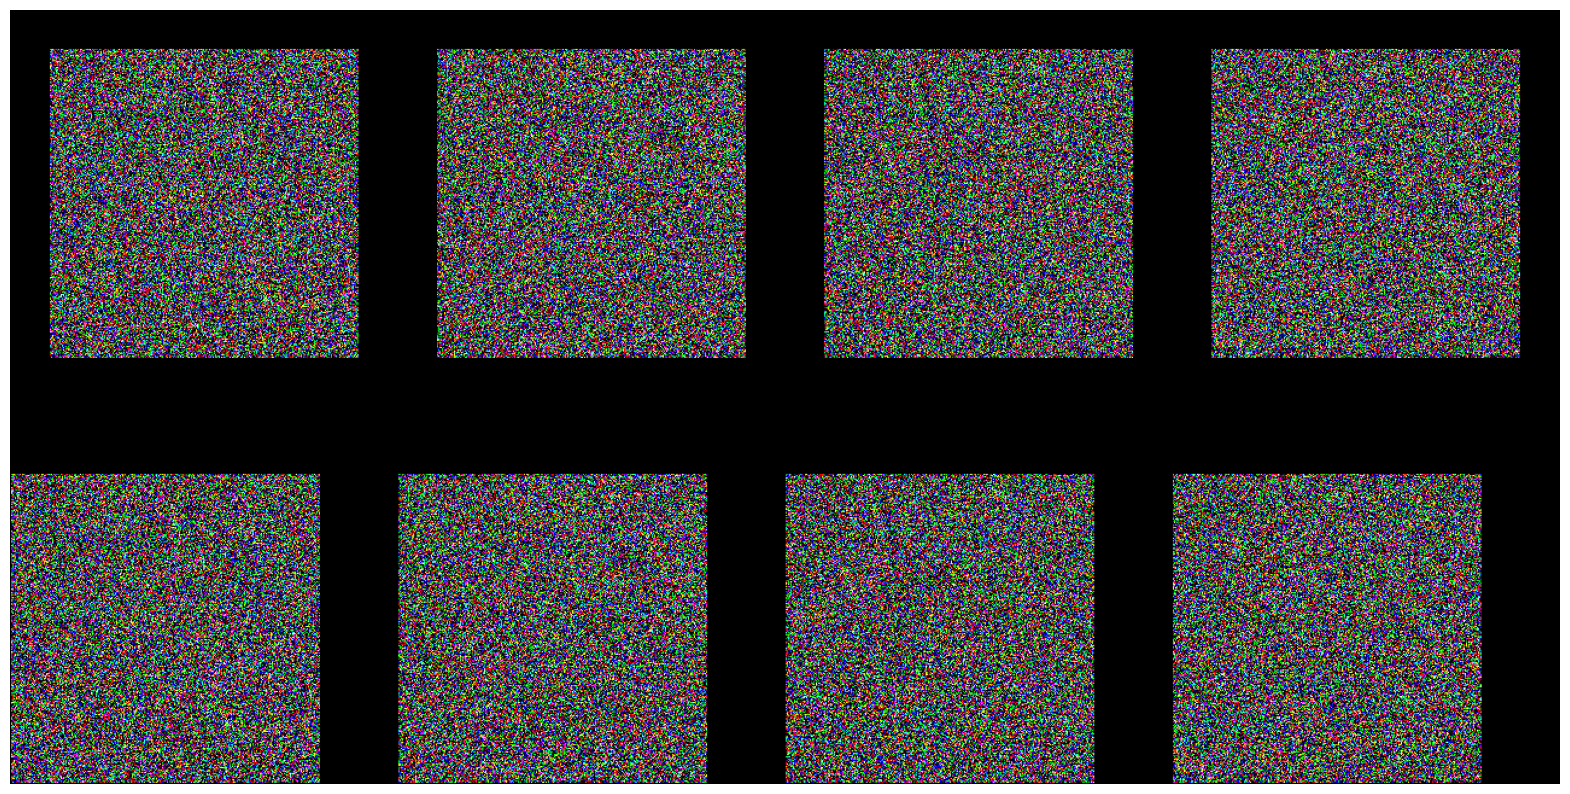

In [5]:
image = torch.randn(4,3,256,256)

padded1 = Fx.pad_to(image, (320,320))
padded2 = Fx.pad_to(image, (320,320), mode=["near","far"])

G.plot(torch.cat([padded1,padded2],-2), size=(5,5))

In [6]:
data = torch.arange(4*5*6).view(4,5,6).float()

console.print("<pink~darkgray><b>Fx.reduce</><gray>(input, reduction='none', dim=None)")

console.print("\n<lime>Common reductions")
a = Fx.reduce(data, "mean")
b = Fx.reduce(data, "sum")
c = Fx.reduce(data, "prod")
console.print("<b>mean:</>", a)
console.print("<b>sum:</>", b)
console.print("<b>prod:</>", c)

console.print("\n<lime>Reduction over specific dimensions")
a = Fx.reduce(data, "mean", dim=1)
b = Fx.reduce(data, "sum", dim=(1,2))
c = Fx.reduce(data, "prod", dim=-1)
console.print("<b>mean:</>\n", a)
console.print("<b>sum:</>\n", b)
console.print("<b>prod:</>\n", c)

console.print("\n<lime>Combinations of reductions over specific dimensions")
a = Fx.reduce(data, { (-1): "mean", None: "prod" })
console.print("<b>mean(-1)+prod:</>\n", a)



Fx.reduce(input, reduction='none', dim=None) 

Common reductions 
mean: tensor(59.5000) 
sum: tensor(7140.) 
prod: tensor(0.) 

Reduction over specific dimensions 
mean:
 tensor([[ 12.,  13.,  14.,  15.,  16.,  17.],
        [ 42.,  43.,  44.,  45.,  46.,  47.],
        [ 72.,  73.,  74.,  75.,  76.,  77.],
        [102., 103., 104., 105., 106., 107.]]) 
sum:
 tensor([ 435., 1335., 2235., 3135.]) 
prod:
 tensor([[0.0000e+00, 3.3264e+05, 8.9107e+06, 7.2682e+07, 3.4201e+08],
        [1.1687e+09, 3.2374e+09, 7.7311e+09, 1.6529e+10, 3.2441e+10],
        [5.9471e+10, 1.0312e+11, 1.7071e+11, 2.7176e+11, 4.1840e+11],
        [6.2576e+11, 9.1248e+11, 1.3012e+12, 1.8191e+12, 2.4985e+12]]) 

Combinations of reductions over specific dimensions 
mean(-1)+prod:
 tensor(7.2392e+32) 


In [12]:
p = nn.parameter.Parameter(torch.zeros(()))
opt = torch.optim.RMSprop([p])
opt.param_groups[0]["params"].append(p)
opt.param_groups

[{'params': [Parameter containing:
   tensor(0., requires_grad=True),
   Parameter containing:
   tensor(0., requires_grad=True)],
  'lr': 0.01,
  'momentum': 0,
  'alpha': 0.99,
  'eps': 1e-08,
  'centered': False,
  'weight_decay': 0,
  'capturable': False,
  'foreach': None,
  'maximize': False,
  'differentiable': False}]